In [1]:
# input
data = {
    "Group": ["WT", "WT", "all mutant","all mutant"],
    "Metal": [ "Zn", "Fe", "Zn", "Fe"],
    "Data": [
        [0.415064, 0.549175, 0.312347], 
        [0.096978, 0.07656, 0.138675], 
        [0.078816, 0.067559, 0.076719],
        [-0.079504, -0.066551, -0.057056], 
    ]
}
# output
fig_file = "./fig/A0A0H3JK28_icp-mass.pdf"

[Text(0.125, 0, 'WT'), Text(1.125, 0, 'H187A & H189A')]

Text(0, 0.5, 'Ratio in mol (ion / protein)')

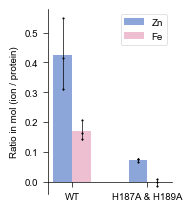

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

means = [np.mean(d) for d in data["Data"]]
correction = abs(means[-1])
means[1] += correction
means[-1] += correction
data["Data"][1] = [i + correction for i in data["Data"][1]]
data["Data"][-1] = [i + correction for i in data["Data"][-1]]

stds = [np.std(d, ddof=1) for d in data["Data"]]

n_groups = 2  # WT, H107A
n_metals = 2  # Ni, Zn
bar_width = 0.25
group_spacing = 0.5
x = np.arange(n_groups) * (n_metals * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(1.6, 2.4))

for i in range(n_metals):
    bars = ax.bar(
        x + i * bar_width,
        means[i::n_metals],
        bar_width,
        label=data["Metal"][i],
        yerr=stds[i::n_metals],
    )
    
    for j, (bx, mean) in enumerate(zip(x + i * bar_width, means[i::n_metals])):
        ax.scatter(
            [bx] * 3,
            data["Data"][i + j * n_metals],
            color="black",
            s=1,
        )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(["WT", "H187A & H189A"])
ax.set_ylabel('Ratio in mol (ion / protein)')
ax.spines['bottom'].set_position(('data', 0))
ax.legend()
plt.savefig(fig_file, transparent=True, bbox_inches='tight')